<a href="https://colab.research.google.com/github/DaviSanttos/trabalho-II-ML/blob/main/trabalho_II.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
sns.set_theme(style="whitegrid", palette='rocket')

In [12]:
from google.colab import drive
drive.mount('/content/drive')
path = "/content/drive/MyDrive/Colab Notebooks"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
df = pd.read_csv(path + '/A519.csv', delimiter=";")

df.head(10)

,data,hora,pressao,radiacao,temp_inst,pto_orvalho_inst,umid_inst,vento_vel,Unnamed: 8
0,2013-12-03,0,949.3,-3.540,22.3,21.0,92.0,2.3,NaN
1,2013-12-03,100,949.7,-3.540,22.1,20.6,91.0,2.1,NaN
2,2013-12-03,200,949.4,-3.540,22.1,20.0,88.0,1.3,NaN
3,2013-12-03,300,949.1,-3.540,21.9,20.2,90.0,2.3,NaN
4,2013-12-03,400,948.6,-3.540,21.4,19.8,91.0,1.5,NaN
5,2013-12-03,500,947.8,-3.540,21.2,19.8,92.0,2.0,NaN
6,2013-12-03,600,947.3,-3.540,20.8,19.4,92.0,1.8,NaN
7,2013-12-03,700,947.7,-3.540,20.4,19.6,95.0,1.7,NaN
8,2013-12-03,800,948.3,-3.445,20.4,19.7,95.0,1.8,NaN
9,2013-12-03,900,949.2,38.054,20.6,19.8,95.0,1.9,NaN


# Analise prévia

In [14]:
df.describe()

,hora,pressao,radiacao,temp_inst,pto_orvalho_inst,umid_inst,vento_vel,Unnamed: 8
count,83232.000000,77953.000000,77953.000000,77953.000000,77948.000000,77947.000000,77953.000000,0.0
mean,1150.000000,950.645189,854.659699,24.266163,15.971423,64.328492,1.797509,NaN
std,692.222814,3.183373,1127.039563,5.117659,4.969063,21.084565,1.377348,NaN
min,0.000000,938.900000,-3.540000,2.000000,-10.000000,8.000000,0.000000,NaN
25%,575.000000,948.500000,-3.529000,21.000000,12.500000,49.000000,0.800000,NaN
50%,1150.000000,950.500000,79.662000,23.600000,17.300000,67.000000,1.500000,NaN
75%,1725.000000,952.700000,1727.162000,28.100000,19.800000,82.000000,2.500000,NaN
max,2300.000000,963.000000,4291.431000,40.900000,33.200000,100.000000,10.300000,NaN


In [15]:
df_clean = df
df_clean = df_clean.loc[:, ~df_clean.columns.str.contains("^Unnamed")]

In [16]:
df_clean.shape

(83232, 8)

In [17]:
df_clean.isnull().sum()

,0
data,0
hora,0
pressao,5279
radiacao,5279
temp_inst,5279
pto_orvalho_inst,5284
umid_inst,5285
vento_vel,5279


In [18]:
df_clean = df_clean.dropna()

In [19]:
df_clean.shape

(77945, 8)

limpando dados null, que não agregariam na analise

## Transformação das Datas

In [20]:
df_clean["data"] = pd.to_datetime(df_clean["data"])

df_clean["ano"] = df_clean["data"].dt.year
df_clean["mes"] = df_clean["data"].dt.month
df_clean["dia"] = df_clean["data"].dt.day

In [21]:
df_clean["hora"] = df_clean["hora"] // 100

tratamento das horas, estava em HH:MM, assim dividindo por 100, para ter exatamente a hora em especifico

In [22]:
df_clean.drop(columns=["data"], inplace=True)

In [23]:
df_clean.head(10)

,hora,pressao,radiacao,temp_inst,pto_orvalho_inst,umid_inst,vento_vel,ano,mes,dia
0,0,949.3,-3.540,22.3,21.0,92.0,2.3,2013,12,3
1,1,949.7,-3.540,22.1,20.6,91.0,2.1,2013,12,3
2,2,949.4,-3.540,22.1,20.0,88.0,1.3,2013,12,3
3,3,949.1,-3.540,21.9,20.2,90.0,2.3,2013,12,3
4,4,948.6,-3.540,21.4,19.8,91.0,1.5,2013,12,3
5,5,947.8,-3.540,21.2,19.8,92.0,2.0,2013,12,3
6,6,947.3,-3.540,20.8,19.4,92.0,1.8,2013,12,3
7,7,947.7,-3.540,20.4,19.6,95.0,1.7,2013,12,3
8,8,948.3,-3.445,20.4,19.7,95.0,1.8,2013,12,3
9,9,949.2,38.054,20.6,19.8,95.0,1.9,2013,12,3


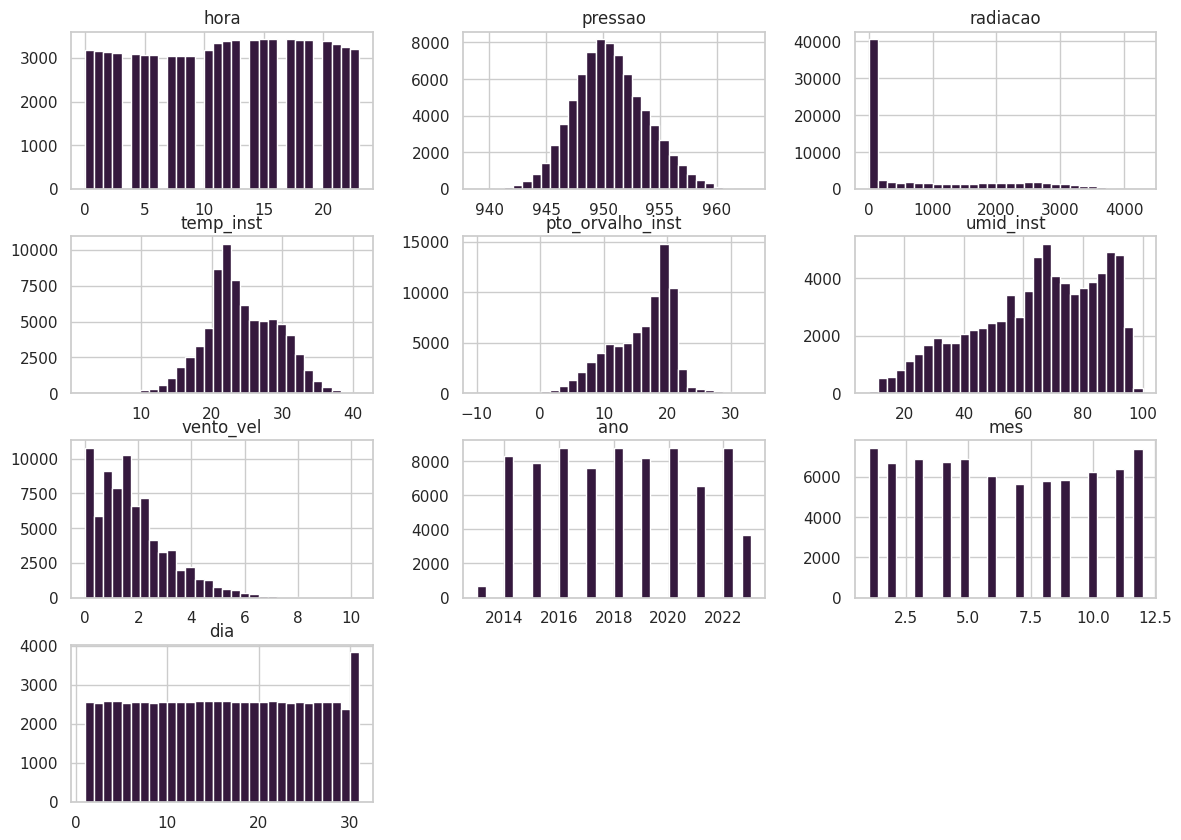

In [24]:
df_clean.hist(
    figsize=(14,10),
    bins=30
)

plt.show()

In [25]:
colunas_numericas = [
    "hora",
    "pressao",
    "radiacao",
    "temp_inst",
    "pto_orvalho_inst",
    "umid_inst",
    "vento_vel",
    "ano",
    "mes",
    "dia"
]

df_num = df_clean[colunas_numericas]

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_scaled = pd.DataFrame(
    scaler.fit_transform(df_num),
    columns=df_num.columns
)

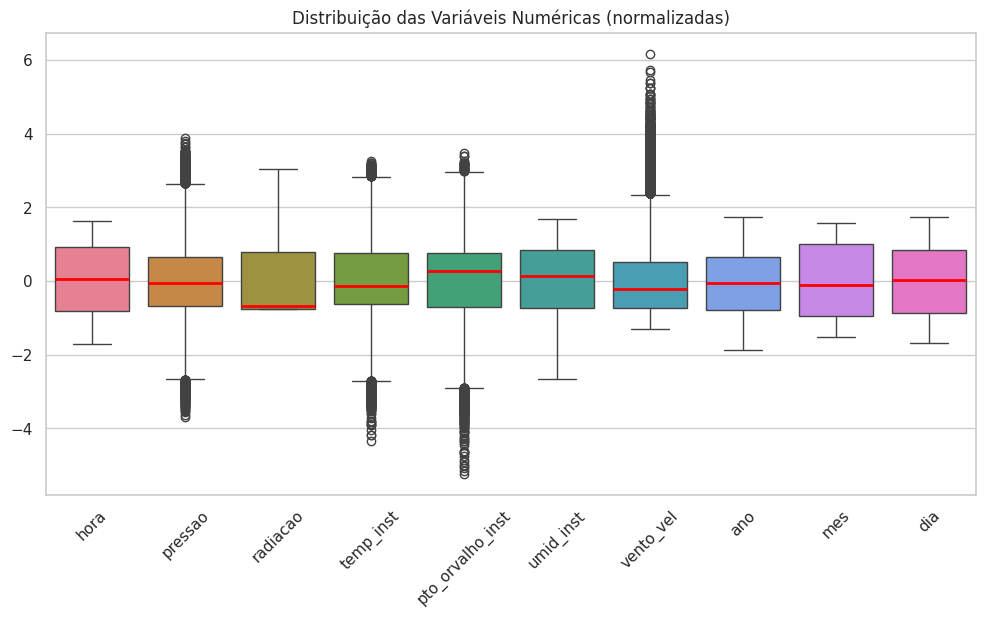

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_scaled,
    medianprops=dict(color="red", linewidth=2)
)

plt.xticks(rotation=45)

plt.title("Distribuição das Variáveis Numéricas (normalizadas)")

plt.show()

In [28]:
Q1 = df_clean['pto_orvalho_inst'].quantile(0.25)
Q3 = df_clean['pto_orvalho_inst'].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR


df_clean.drop(
    df_clean[
        (df_clean['pto_orvalho_inst'] < limite_inferior) |
        (df_clean['pto_orvalho_inst'] > limite_superior)
    ].index,
    inplace=True
)

In [29]:
df_clean.drop(
    df_clean[df_clean['vento_vel'] < 0].index,
    inplace=True
)

Q1 = df_clean['vento_vel'].quantile(0.25)
Q3 = df_clean['vento_vel'].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR


df_clean.drop(
    df_clean[
        (df_clean['vento_vel'] < limite_inferior) |
        (df_clean['vento_vel'] > limite_superior)
    ].index,
    inplace=True
)

In [30]:
Q1 = df_clean['temp_inst'].quantile(0.25)
Q3 = df_clean['temp_inst'].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR


df_clean.drop(
    df_clean[
        (df_clean['temp_inst'] < limite_inferior) |
        (df_clean['temp_inst'] > limite_superior)
    ].index,
    inplace=True
)

In [31]:
df_clean.drop(
    df_clean[df_clean['pressao'] < 0].index,
    inplace=True
)

Q1 = df_clean['pressao'].quantile(0.25)
Q3 = df_clean['pressao'].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR


df_clean.drop(
    df_clean[
        (df_clean['pressao'] < limite_inferior) |
        (df_clean['pressao'] > limite_superior)
    ].index,
    inplace=True
)

In [32]:
df_num = df_clean[colunas_numericas]

scaler = StandardScaler()

df_scaled = pd.DataFrame(
    scaler.fit_transform(df_num),
    columns=df_num.columns
)

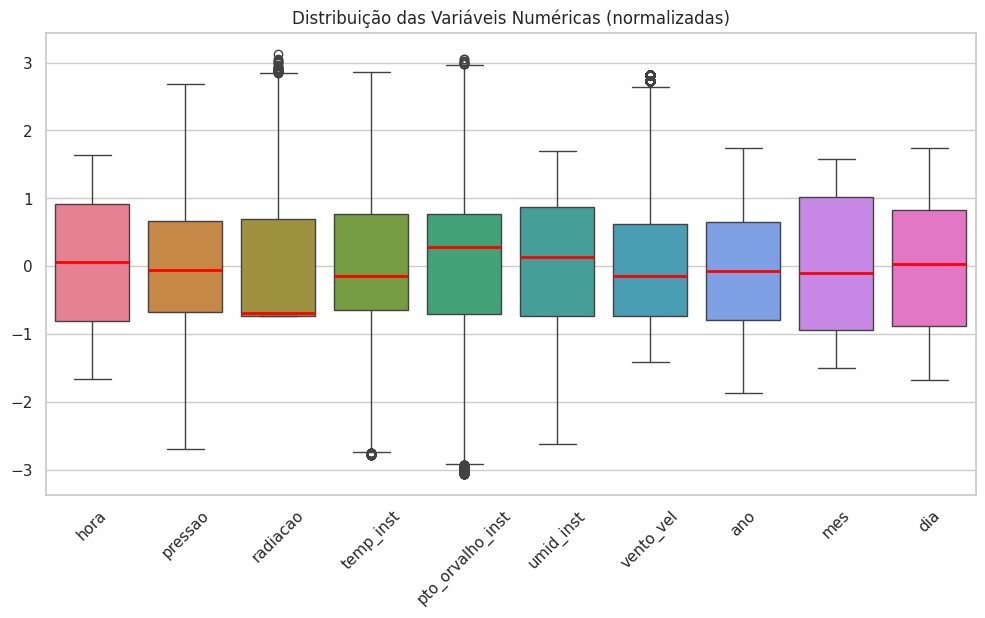

In [33]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_scaled,
    medianprops=dict(color="red", linewidth=2)
)

plt.xticks(rotation=45)

plt.title("Distribuição das Variáveis Numéricas (normalizadas)")

plt.show()

In [34]:
df_clean.shape

(74157, 10)

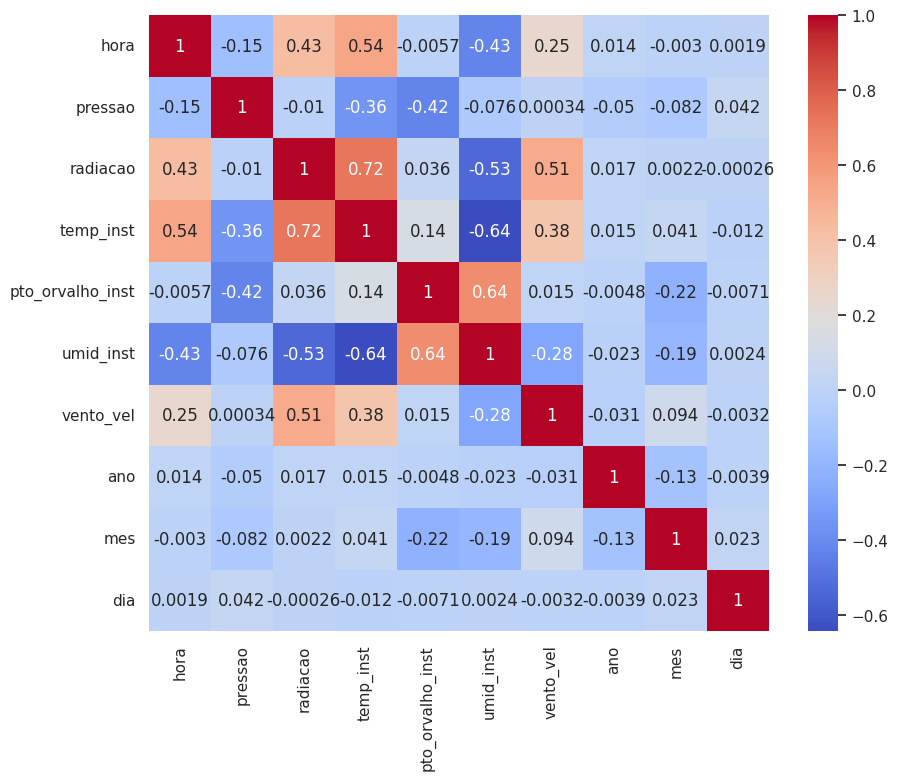

In [35]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df_clean.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

# Exploração de Modelos

In [36]:
## separando dados de entrada e dado para previsão
X = df_clean.drop(columns=['temp_inst'])
y = df_clean['temp_inst']

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [39]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def avaliar_modelo(nome, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {"Modelo": nome, "MAE": mae, "RMSE": rmse, "R2": r2}

resultados = []

In [40]:
### ÁRVORE DE DECISÃO

from sklearn.tree import DecisionTreeRegressor

tree1 = DecisionTreeRegressor(max_depth=3, random_state=42)
tree1.fit(X_train, y_train)
pred1 = tree1.predict(X_test)

resultados.append(avaliar_modelo("Tree depth=3", y_test, pred1))

In [41]:
tree2 = DecisionTreeRegressor(max_depth=5, min_samples_leaf=5, random_state=42)
tree2.fit(X_train, y_train)
pred2 = tree2.predict(X_test)

resultados.append(avaliar_modelo("Tree depth=5 leaf=5", y_test, pred2))

In [42]:
tree3 = DecisionTreeRegressor(max_depth=10, min_samples_split=10, random_state=42)
tree3.fit(X_train, y_train)
pred3 = tree3.predict(X_test)

resultados.append(avaliar_modelo("Tree depth=10 split=10", y_test, pred3))

In [43]:
### RANDOM FOREST

from sklearn.ensemble import RandomForestRegressor

rf1 = RandomForestRegressor(n_estimators=50, max_depth=5, random_state=42, max_features='sqrt', bootstrap=True)
rf1.fit(X_train, y_train)
pred1 = rf1.predict(X_test)

resultados.append(avaliar_modelo("RF 50 trees depth=5", y_test, pred1))

In [44]:
rf2 = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, max_features='sqrt', bootstrap=True)
rf2.fit(X_train, y_train)
pred2 = rf2.predict(X_test)

resultados.append(avaliar_modelo("RF 100 trees depth=10", y_test, pred2))

In [45]:
rf3 = RandomForestRegressor(n_estimators=200, max_depth=None, random_state=42, max_features='sqrt', bootstrap=True)
rf3.fit(X_train, y_train)
pred3 = rf3.predict(X_test)

resultados.append(avaliar_modelo("RF 200 trees full", y_test, pred3))

In [46]:
## 4. SVR (3 variações)
from sklearn.svm import SVR

svr1 = SVR(kernel="linear", C=1, epsilon=0.1)
svr1.fit(X_train_scaled, y_train)
pred1 = svr1.predict(X_test_scaled)

resultados.append(avaliar_modelo("SVR linear C=1", y_test, pred1))

In [47]:
svr2 = SVR(kernel="poly", C=2, epsilon=0.1)
svr2.fit(X_train_scaled, y_train)
pred2 = svr2.predict(X_test_scaled)

resultados.append(avaliar_modelo("SVR poly C=2", y_test, pred2))

In [48]:
svr3 = SVR(kernel="rbf", C=3, epsilon=0.01)
svr3.fit(X_train_scaled, y_train)
pred3 = svr3.predict(X_test_scaled)

resultados.append(avaliar_modelo("SVR rbf C=3", y_test, pred3))

In [49]:
## REGRESSÃO LINEAR

from sklearn.linear_model import ElasticNet

lr1 = ElasticNet(
    alpha=0.01,
    l1_ratio=0.2,
    random_state=42
)

lr1.fit(X_train_scaled, y_train)

pred1 = lr1.predict(X_test_scaled)

resultados.append(
    avaliar_modelo(
        "ElasticNet alpha=0.01 l1=0.2",
        y_test,
        pred1
    )
)

In [50]:
lr2 = ElasticNet(
    alpha=0.1,
    l1_ratio=0.5,
    random_state=42
)

lr2.fit(X_train_scaled, y_train)

pred2 = lr2.predict(X_test_scaled)

resultados.append(
    avaliar_modelo(
        "ElasticNet alpha=0.1 l1=0.5",
        y_test,
        pred2
    )
)

In [51]:
lr3 = ElasticNet(
    alpha=1.0,
    l1_ratio=0.8,
    random_state=42
)

lr3.fit(X_train_scaled, y_train)

pred3 = lr3.predict(X_test_scaled)

resultados.append(
    avaliar_modelo(
        "ElasticNet alpha=1.0 l1=0.8",
        y_test,
        pred3
    )
)

# Metricas e avaliação

In [52]:
import pandas as pd

df_resultados = pd.DataFrame(resultados)
df_resultados.sort_values(by="R2", ascending=False)

,Modelo,MAE,RMSE,R2
8,SVR rbf C=3,0.099372,0.151023,0.999069
5,RF 200 trees full,0.336555,0.520461,0.988949
2,Tree depth=10 split=10,0.411467,0.611858,0.984726
4,RF 100 trees depth=10,0.711616,0.965419,0.961975
7,SVR poly C=2,0.874840,1.245911,0.936669
9,ElasticNet alpha=0.01 l1=0.2,0.990044,1.337168,0.927052
10,ElasticNet alpha=0.1 l1=0.5,1.117632,1.495582,0.908744
6,SVR linear C=1,0.889564,1.570451,0.899379
1,Tree depth=5 leaf=5,1.394082,1.842749,0.861461
3,RF 50 trees depth=5,1.396384,1.845803,0.861002


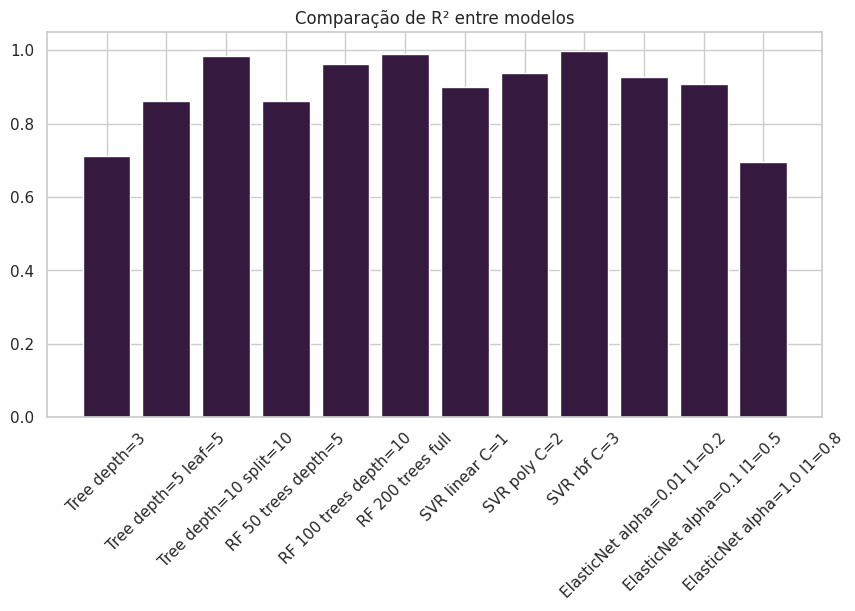

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(df_resultados["Modelo"], df_resultados["R2"])
plt.xticks(rotation=45)
plt.title("Comparação de R² entre modelos")
plt.show()

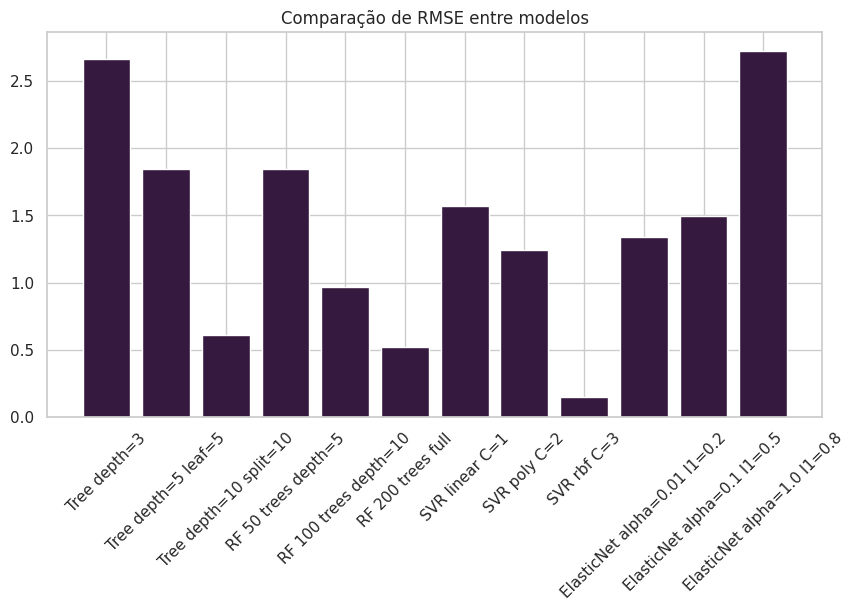

In [54]:
## Gráfico RMSE

plt.figure(figsize=(10,5))
plt.bar(df_resultados["Modelo"], df_resultados["RMSE"])
plt.xticks(rotation=45)
plt.title("Comparação de RMSE entre modelos")
plt.show()

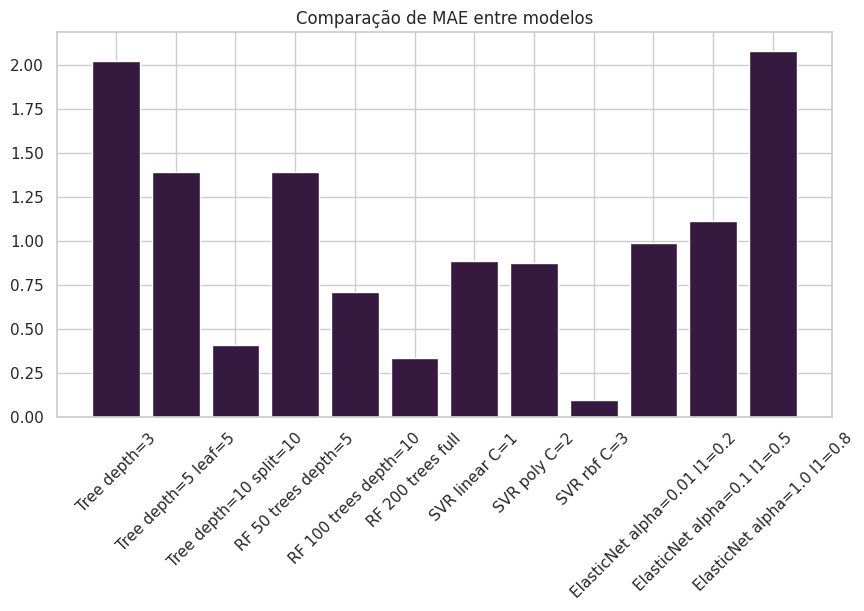

In [55]:
## Gráfico de MAE
plt.figure(figsize=(10,5))
plt.bar(df_resultados["Modelo"], df_resultados["MAE"])
plt.xticks(rotation=45)
plt.title("Comparação de MAE entre modelos")
plt.show()

## Conclusão

Foram avaliados quatro algoritmos de regressão diferentes — **Árvore de Decisão**, **Random Forest**, **SVR (Support Vector Regression)** e **ElasticNet** — cada um com diferentes configurações de hiperparâmetros, totalizando **12 modelos**.

Os resultados demonstram que o modelo **SVR com kernel RBF e C = 3** apresentou o melhor desempenho geral, obtendo:

- **MAE = 0,099**
- **RMSE = 0,151**
- **R² = 0,999**

Esses valores indicam um erro extremamente baixo e uma capacidade de explicação de aproximadamente **99,9% da variabilidade dos dados**, tornando-o o modelo mais preciso entre todos os avaliados.

Entre os modelos baseados em árvores, o melhor resultado foi obtido pelo **Random Forest com 200 árvores e profundidade livre**, alcançando:

- **MAE = 0,337**
- **RMSE = 0,520**
- **R² = 0,989**

Esse desempenho evidencia a eficiência dos métodos de *ensemble*, que conseguiram superar significativamente as Árvores de Decisão individuais.

As **Árvores de Decisão** apresentaram melhora conforme o aumento da profundidade do modelo. A configuração com **profundidade 10 e mínimo de 10 amostras para divisão** atingiu **R² = 0,985**, enquanto a árvore mais simples, com **profundidade 3**, obteve apenas **R² = 0,710**. Esse resultado demonstra que modelos muito simples não conseguem capturar adequadamente os padrões presentes nos dados, ocasionando subajuste (*underfitting*).

Os modelos **ElasticNet** apresentaram desempenho intermediário. A configuração com **alpha = 0,01 e l1_ratio = 0,2** foi a melhor entre elas, alcançando:

- **MAE = 0,990**
- **RMSE = 1,337**
- **R² = 0,927**

Por outro lado, a configuração com maior regularização (**alpha = 1,0 e l1_ratio = 0,8**) apresentou uma queda significativa de desempenho, obtendo **R² = 0,697**, indicando que o excesso de regularização prejudicou a capacidade de generalização do modelo.

Ao analisar as diferentes configurações de cada algoritmo, observa-se que a escolha dos hiperparâmetros impacta diretamente a qualidade das previsões. Em especial, o **SVR** mostrou grande sensibilidade à escolha do kernel, apresentando uma evolução de **R² = 0,899** no modelo linear para **R² = 0,999** no modelo com kernel RBF.

De forma geral, os resultados indicam que os dados possuem **relações não lineares complexas**, uma vez que os modelos capazes de capturar essas não linearidades — especialmente o **SVR com kernel RBF** e o **Random Forest** — obtiveram desempenho superior aos modelos lineares e às árvores mais simples.

Portanto, considerando todas as métricas avaliadas, o **SVR com kernel RBF e C = 3** foi o modelo mais adequado para o problema estudado, apresentando os menores erros de previsão e o maior coeficiente de determinação entre todos os modelos testados.